In [1]:
import numpy as np
from matplotlib import rc,rcParams
#matplotlib.use('Agg')
import matplotlib.pyplot as plt
from astropy.io import fits
%matplotlib inline 
import os
from astropy.table import Table, vstack
from scipy import stats
from astropy.cosmology import Planck18 as cosmo
import astropy.coordinates as coord
from scipy import stats
import statsmodels.api as sm
import pdb
import copy


In [2]:
    def set_rc_params(fontsize=None):

        print("Setting Matplotlib RC parameters...")

        if fontsize is None:
            fontsize=16
        else:
            fontsize=int(fontsize)

        rc('font',**{'family':'serif'})
        rc('text', usetex=True)

        #plt.rcParams.update({'figure.facecolor':'w'})
        plt.rcParams.update({'axes.linewidth': 1.1})
        plt.rcParams.update({'xtick.labelsize': fontsize})
        plt.rcParams.update({'ytick.labelsize': fontsize})
        plt.rcParams.update({'xtick.major.size': 8})
        plt.rcParams.update({'xtick.major.width': 1.1})
        plt.rcParams.update({'xtick.minor.visible': True})
        plt.rcParams.update({'xtick.minor.width': 1.})
        plt.rcParams.update({'xtick.minor.size': 6})
        plt.rcParams.update({'xtick.direction': 'out'})
        plt.rcParams.update({'ytick.major.width': 1.1})
        plt.rcParams.update({'ytick.major.size': 8})
        plt.rcParams.update({'ytick.minor.visible': True})
        plt.rcParams.update({'ytick.minor.width': 1.})
        plt.rcParams.update({'ytick.minor.size':6})
        plt.rcParams.update({'ytick.direction':'out'})
        plt.rcParams.update({'axes.labelsize': fontsize})
        plt.rcParams.update({'axes.titlesize': fontsize})
        plt.rcParams.update({'legend.fontsize': int(fontsize-2)})

        return


In [3]:
set_rc_params(fontsize=16)

Setting Matplotlib RC parameters...


# Compare CSFD to SFD

## Start with SFD redMaGiC catalogs

## CSFD redMaGiC catalogs

In [4]:
###
### CSFD hidens, with and without bins plus one with a redshift cut
###
output_path = '/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/redmagic_hidens_csfd/'

### NOTE: THIS HAD BUGGY WISE RANDOMS
dk_hidens_csfd = Table.read(output_path+'z_gt_0.5_dustcorrel_g23_usebins_compensated_signal.txt', header_start=1, format='ascii')
dr_hidens_csfd = Table.read(output_path+'z_gt_0.5_dustcorrel_g23_usebins_bg_randoms.txt', header_start=1, format='ascii')
fr_hidens_csfd = Table.read(output_path+'z_gt_0.5_dustcorrel_g23_usebins_fg_randoms.txt', header_start=1, format='ascii')
rr_hidens_csfd = Table.read(output_path+'z_gt_0.5_dustcorrel_g23_usebins_fgxbg_randoms.txt', header_start=1, format='ascii')

### WISE randoms have been fixed in this version
dk_hidens_newrand_csfd = Table.read(output_path+'z_gt_0.5_dustcorrel_usebins_new_wiserand_compensated_signal.txt', header_start=1, format='ascii')
dr_hidens_newrand_csfd = Table.read(output_path+'z_gt_0.5_dustcorrel_usebins_new_wiserand_bg_randoms.txt', header_start=1, format='ascii')
fr_hidens_newrand_csfd = Table.read(output_path+'z_gt_0.5_dustcorrel_usebins_new_wiserand_fg_randoms.txt', header_start=1, format='ascii')
rr_hidens_newrand_csfd = Table.read(output_path+'z_gt_0.5_dustcorrel_usebins_new_wiserand_fgxbg_randoms.txt', header_start=1, format='ascii')

### NOTE: THIS HAD BUGGY WISE RANDOMS
dk_zcut_csfd = Table.read(output_path+'z_gt_0.5_dustcorrel_wise_zlt0.11_g23_usebins_compensated_signal.txt', header_start=1, format='ascii')
dr_zcut_csfd = Table.read(output_path+'z_gt_0.5_dustcorrel_wise_zlt0.11_g23_usebins_bg_randoms.txt', header_start=1, format='ascii')
fr_zcut_csfd = Table.read(output_path+'z_gt_0.5_dustcorrel_wise_zlt0.11_g23_usebins_fg_randoms.txt', header_start=1, format='ascii')
rr_zcut_csfd = Table.read(output_path+'z_gt_0.5_dustcorrel_wise_zlt0.11_g23_usebins_fgxbg_randoms.txt', header_start=1, format='ascii')

###
### high-lum high-z CSFD
###

output_path_hiz = '/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/redmagic_hiz_csfd/'

### NOTE: THIS HAD BUGGY WISE RANDOMS
dk_hiz_csfd = Table.read(output_path_hiz+'dustcorrel_g23_usebins_compensated_signal.txt', header_start=1, format='ascii')
dr_hiz_csfd = Table.read(output_path_hiz+'dustcorrel_g23_usebins_bg_randoms.txt', header_start=1, format='ascii')
fr_hiz_csfd = Table.read(output_path_hiz+'dustcorrel_g23_usebins_fg_randoms.txt', header_start=1, format='ascii')
raw_hiz_csfd = Table.read(output_path_hiz+'dustcorrel_g23_usebins_raw_signal.txt', header_start=1, format='ascii')
rr_hiz_csfd = Table.read(output_path_hiz+'dustcorrel_g23_usebins_fgxbg_randoms.txt', header_start=1, format='ascii')

### WISE randoms have been fixed in this version
dk_hiz_newrand_csfd = Table.read(output_path_hiz+'dustcorrel_usebins_wise_compensated_signal.txt', header_start=1, format='ascii')
dr_hiz_newrand_csfd = Table.read(output_path_hiz+'dustcorrel_usebins_wise_bg_randoms.txt', header_start=1, format='ascii')
fr_hiz_newrand_csfd = Table.read(output_path_hiz+'dustcorrel_usebins_wise_fg_randoms.txt', header_start=1, format='ascii')
raw_hiz_newrand_csfd = Table.read(output_path_hiz+'dustcorrel_usebins_wise_raw_signal.txt', header_start=1, format='ascii')
rr_hiz_newrand_csfd = Table.read(output_path_hiz+'dustcorrel_usebins_wise_fgxbg_randoms.txt', header_start=1, format='ascii')



### Read in redMaGiC LRGs

In [5]:
output_path = '/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/lowz_hidens_fg_x_hiz_bg/'

### NOTE: THIS HAD BUGGY WISE RANDOMS
dk_lrg = Table.read(output_path+'dustcorrel_g23_5zbins_compensated_signal.txt', header_start=1, format='ascii')
dr_lrg = Table.read(output_path+'dustcorrel_g23_5zbins_bg_randoms.txt', header_start=1, format='ascii')
fr_lrg = Table.read(output_path+'dustcorrel_g23_5zbins_fg_randoms.txt', header_start=1, format='ascii')
rr_lrg = Table.read(output_path+'dustcorrel_g23_5zbins_fgxbg_randoms.txt', header_start=1, format='ascii')

### WISE randoms have been fixed in this version
dk_lrg_usebins_csfd = Table.read(output_path+'dustcorrel_g23_csfd_usebins_compensated_signal.txt', header_start=1, format='ascii')
dr_lrg_usebins_csfd = Table.read(output_path+'dustcorrel_g23_csfd_usebins_bg_randoms.txt', header_start=1, format='ascii')
fr_lrg_usebins_csfd = Table.read(output_path+'dustcorrel_g23_csfd_usebins_fg_randoms.txt', header_start=1, format='ascii')
rr_lrg_usebins_csfd = Table.read(output_path+'dustcorrel_g23_csfd_usebins_fgxbg_randoms.txt', header_start=1, format='ascii')


## Define dust vectors

In [6]:
##
## Hi-density traditional SFD
#dust_hidens = dk['kappa'] - dr['kappa'] + rr['kappa']
#dust_hidens_usebins = dk_usebins['kappa'] - dr_usebins['kappa'] + rr_usebins['kappa']
##
## Hi-density CSFD incl zcut
dust_hidens_csfd = dk_hidens_csfd['kappa'] - dr_hidens_csfd['kappa'] + rr_hidens_csfd['kappa']
dust_hidens_newrand_csfd = dk_hidens_newrand_csfd['kappa'] - dr_hidens_newrand_csfd['kappa'] + rr_hidens_newrand_csfd['kappa']
dust_hidens_zcut_csfd = dk_zcut_csfd['kappa'] - dr_zcut_csfd['kappa'] + rr_zcut_csfd['kappa']

##
## Hi-lum hi-z traditional SFD
#dust_hiz = dk_hiz['kappa'] - dr_hiz['kappa'] + rr_hiz['kappa']

##
## Hi-lum hiz CSFD dk_hiz_usebins_csfd
dust_hiz_csfd = dk_hiz_csfd['kappa'] - dr_hiz_csfd['kappa'] + rr_hiz_csfd['kappa']
dust_hiz_newrand_csfd = dk_hiz_newrand_csfd['kappa'] - dr_hiz_newrand_csfd['kappa'] + rr_hiz_newrand_csfd['kappa']

##
## redMaGic LRG sample (lowz_hidens_fg x hiz_bg)
dust_lrg = dk_lrg['kappa'] - dr_lrg['kappa'] + rr_lrg['kappa']
##
## redMaGic LRG sample (lowz_hidens_fg x hiz_bg) usebins + CSFD
dust_lrg_usebins_csfd = dk_lrg_usebins_csfd['kappa'] - dr_lrg_usebins_csfd['kappa'] + rr_lrg_usebins_csfd['kappa']


# Make some plots!

### Start with defining theory vector

In [7]:
z_theory = 0.36 # Menard
theory_kpc = cosmo.kpc_proper_per_arcmin(z_theory)
theory_r_arcmin = np.logspace(-5,5,20)
theory_r = theory_r_arcmin * theory_kpc.value * cosmo.h
coeff = 5.5e-3
av_scale = 100
av = coeff * (theory_r/av_scale)**(-0.86)

### Plot: high-density

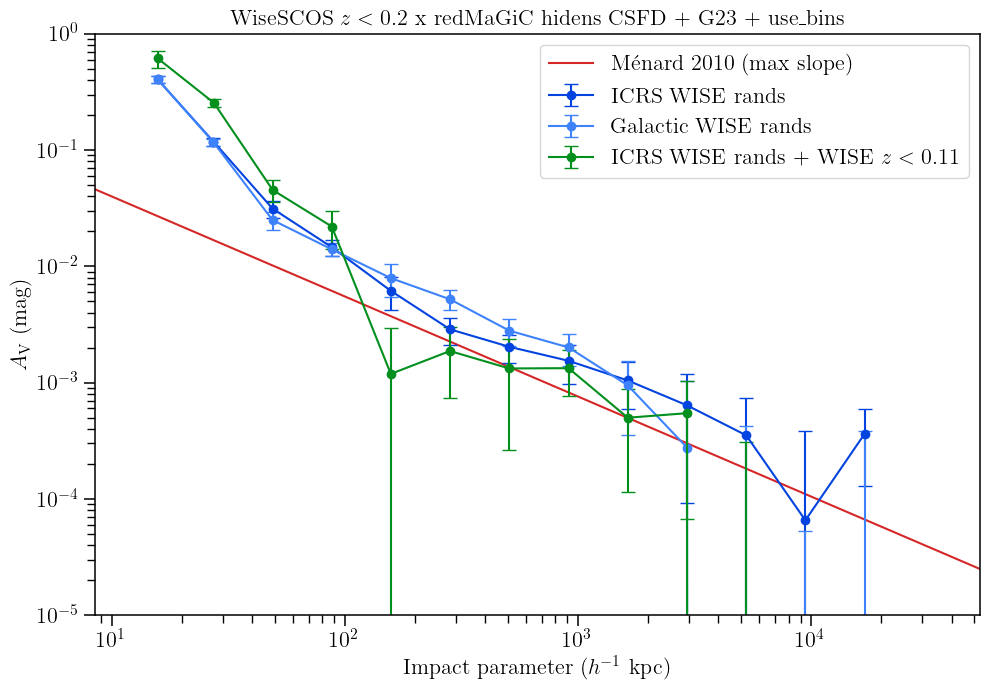

In [8]:
z_fg = 0.144 # Filtered WISExSCOS
fg_gal_kpc = cosmo.kpc_proper_per_arcmin(z_fg)

# Converts us from arcminutes to h^-1 kpc 
# Menard relationship was in terms of h
scl = fg_gal_kpc.value * cosmo.h

fig, ax = plt.subplots(figsize=(10, 7), tight_layout=True)

ax.plot(theory_r, av, color='tab:red',
        label=r'M\'{e}nard 2010 (max slope)')
# Part 1

# What it says
ax.errorbar(dk_hidens_csfd['meanr']*scl, dust_hidens_csfd,
            yerr=dk_hidens_csfd['sigma'], fmt='-o', capsize=5, 
            color='xkcd:blue', label=r'ICRS WISE rands')

ax.errorbar(dk_hidens_newrand_csfd['meanr']*scl, dust_hidens_newrand_csfd,
            yerr=dk_hidens_newrand_csfd['sigma'], fmt='-o', capsize=5, 
            color='xkcd:dodger blue', label=r'Galactic WISE rands')
'''
ax.errorbar(dk_csfd['meanr']*scl, dust_hidens_csfd,
            yerr=dk_csfd['sigma'], fmt='-o', capsize=5, 
            color='xkcd:kelly green', label=r'CSFD 5 zbins')
'''
ax.errorbar(dk_zcut_csfd['meanr']*scl, dust_hidens_zcut_csfd,
            yerr=dk_zcut_csfd['sigma'], fmt='-o', capsize=5, 
            color='xkcd:emerald green', label=r'ICRS WISE rands + WISE $z < 0.11$')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(0.08*scl, 500*scl)
ax.set_ylim(1E-5, 1)
ax.set_xlabel(r'Impact parameter ($h^{-1}$ kpc)', fontsize=16)
ax.set_ylabel(r'$A_{\rm V}$ (mag)', fontsize=16)
ax.set_title(r'WiseSCOS $z < 0.2$ x redMaGiC hidens CSFD + G23 + use\_bins', fontsize=16)
ax.legend(fontsize=16)

figname = 'dustcorrel_csfd_hidens_randcomp.png'
fig.savefig(f"/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/{figname}" )
fig.savefig(f"/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/writeup/figures_update2/{figname}" )


### Plot: high-lum high-z

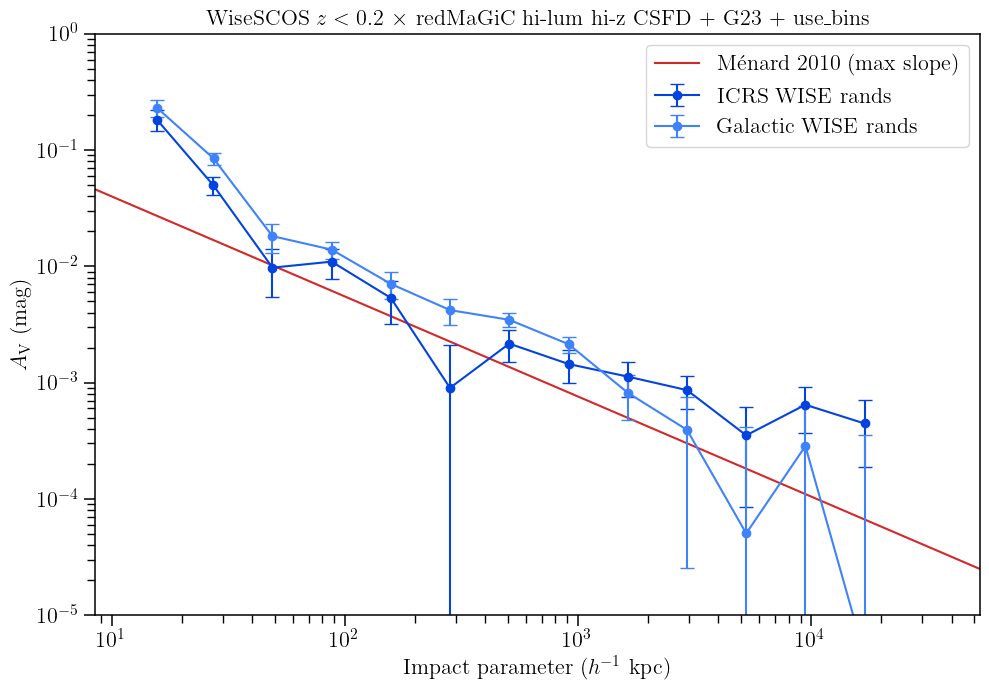

In [9]:
# Set z_theory and z_foreground levels
z_fg = 0.144 # Filtered WISExSCOS
fg_gal_kpc = cosmo.kpc_proper_per_arcmin(z_fg)

# Converts us from arcminutes to h^-1 kpc 
# Menard relationship was in terms of h
scl = fg_gal_kpc.value * cosmo.h

fig, ax = plt.subplots(figsize=(10, 7), tight_layout=True)

ax.plot(theory_r, av, color='tab:red',
        label=r'M\'{e}nard 2010 (max slope)')
# What it says
ax.errorbar(dk_hiz_csfd['meanr']*scl, dust_hiz_csfd,
            yerr=dk_hiz_csfd['sigma'], fmt='-o', capsize=5, 
            color='xkcd:blue', label=r'ICRS WISE rands')

ax.errorbar(dk_hiz_newrand_csfd['meanr']*scl, dust_hiz_newrand_csfd,
            yerr=dk_hiz_newrand_csfd['sigma'], fmt='-o', capsize=5, 
            color='xkcd:dodger blue', label=r'Galactic WISE rands')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(0.08*scl, 500*scl)
ax.set_ylim(1E-5, 1)
ax.set_xlabel(r'Impact parameter ($h^{-1}$ kpc)', fontsize=16)
ax.set_ylabel(r'$A_{\rm V}$ (mag)', fontsize=16)
ax.set_title(r'WiseSCOS $z < 0.2 \ \times $ redMaGiC hi-lum hi-z CSFD + G23 + use\_bins', fontsize=16)
ax.legend(fontsize=16)

figname = 'dustcorrel_csfd_hiz_randcomp.png'
fig.savefig(f"/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/{figname}" )
fig.savefig(f"/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/writeup/figures_update2/{figname}" )


### Plot: redMaGiC LRG (`lowz_hidens_fg_x_hiz_bg`)

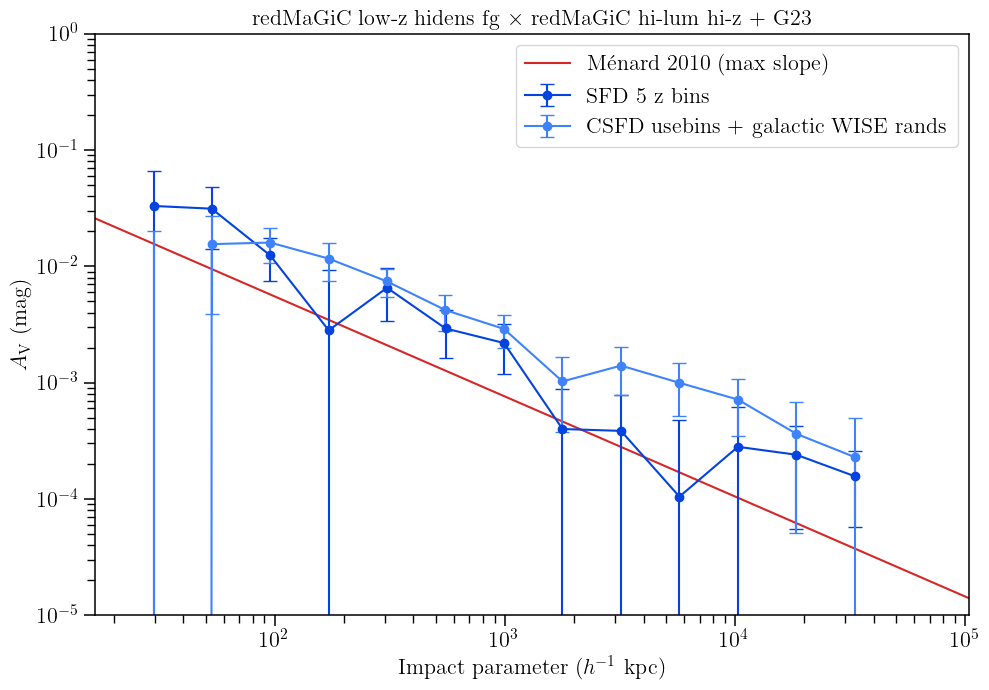

In [10]:
# Set z_theory and z_foreground levels
z_fg = 0.35 # lowz redmagic catalog
fg_gal_kpc = cosmo.kpc_proper_per_arcmin(z_fg)

# Converts us from arcminutes to h^-1 kpc 
# Menard relationship was in terms of h
scl = fg_gal_kpc.value * cosmo.h

fig, ax = plt.subplots(figsize=(10, 7), tight_layout=True)

ax.plot(theory_r, av, color='tab:red',
        label=r'M\'{e}nard 2010 (max slope)')

ax.errorbar(dk_lrg['meanr']*scl, dust_lrg,
            yerr=dk_lrg['sigma'], fmt='-o', capsize=5, 
            color='xkcd:blue', label=r'SFD 5 z bins')

ax.errorbar(dk_lrg_usebins_csfd['meanr']*scl, dust_lrg_usebins_csfd,
            yerr=dk_lrg_usebins_csfd['sigma'], fmt='-o', capsize=5, 
            color='xkcd:dodger blue', label=r'CSFD usebins + galactic WISE rands')


ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(0.08*scl, 500*scl)
ax.set_ylim(1E-5, 1)
ax.set_xlabel(r'Impact parameter ($h^{-1}$ kpc)', fontsize=16)
ax.set_ylabel(r'$A_{\rm V}$ (mag)', fontsize=16)
ax.set_title(r'redMaGiC low-z hidens fg $\times$ redMaGiC hi-lum hi-z + G23', fontsize=16)
ax.legend(fontsize=16)

figname = 'dustcorrel_lowz_hidens_fg_x_hiz_bg_csfd_randcomp.png'
fig.savefig(f"/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/{figname}" )
fig.savefig(f"/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/writeup/figures_update2/{figname}" )


### Plot: all CSFD samples

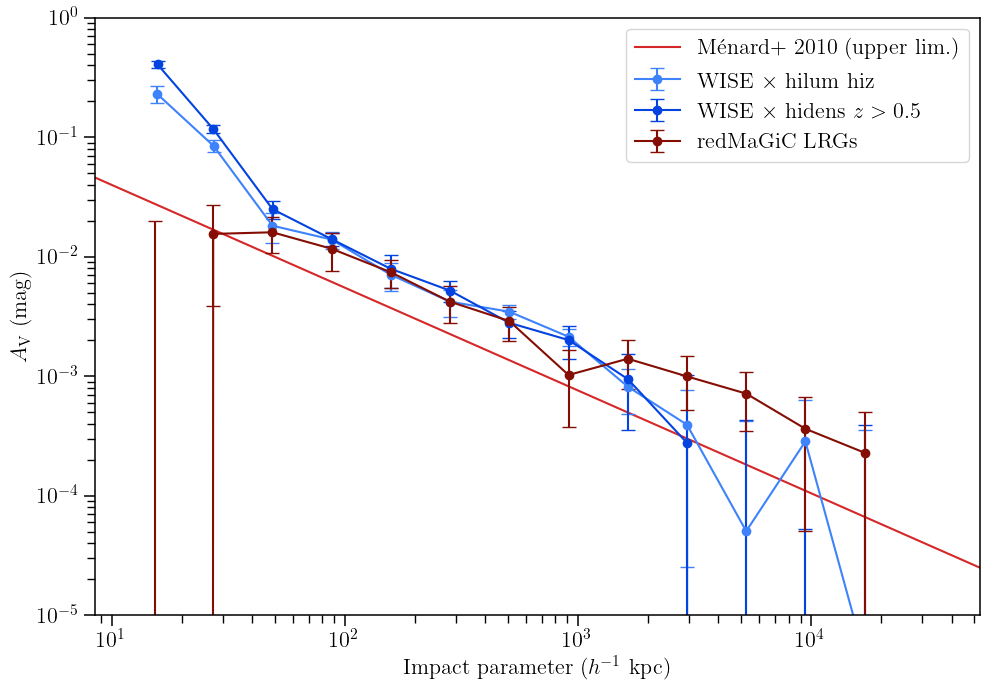

In [11]:
# Set z_theory and z_foreground levels
z_fg = 0.144
z_fg2 = 0.35 # Filtered WISExSCOS
fg_gal_kpc = cosmo.kpc_proper_per_arcmin(z_fg)
fg_gal_kpc2 = cosmo.kpc_proper_per_arcmin(z_fg)

# Converts us from arcminutes to h^-1 kpc 
# Menard relationship was in terms of h
scl = fg_gal_kpc.value * cosmo.h
scl2 = fg_gal_kpc2.value * cosmo.h

fig, ax = plt.subplots(figsize=(10, 7), tight_layout=True)

ax.plot(theory_r, av, color='tab:red',
        label=r'M\'{e}nard+ 2010 (upper lim.)')
# What it says

ax.errorbar(dk_hiz_newrand_csfd['meanr']*scl, dust_hiz_newrand_csfd,
            yerr=dk_hiz_newrand_csfd['sigma'], fmt='-o', capsize=5, 
            color='xkcd:dodger blue', label=r'WISE $\times$ hilum hiz')

ax.errorbar(dk_hidens_newrand_csfd['meanr']*scl, dust_hidens_newrand_csfd,
            yerr=dk_hidens_newrand_csfd['sigma'], fmt='-o', capsize=5, 
            color='xkcd:blue', label=r'WISE $\times$ hidens $z>0.5$')

ax.errorbar(dk_lrg_usebins_csfd['meanr']*scl2, dust_lrg_usebins_csfd,
            yerr=dk_lrg_usebins_csfd['sigma'], fmt='-o', capsize=5, 
            color='xkcd:indian red', label=r'redMaGiC LRGs')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(0.08*scl, 500*scl)
ax.set_ylim(1E-5, 1)
ax.set_xlabel(r'Impact parameter ($h^{-1}$ kpc)', fontsize=16)
ax.set_ylabel(r'$A_{\rm V}$ (mag)', fontsize=16)
#ax.set_title(r'', fontsize=16)
ax.legend(fontsize=16)

figname = 'dustcorrel_redmagic_csfd_newrand_comp.png'
fig.savefig(f"/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/{figname}" )
fig.savefig(f"/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/writeup/figures_update2/{figname}" )


# Calculate fits

In [12]:
def do_WLS_fit(this_dk, dust_rel, name=None, start=None, end=None, log=False):
    """
    Perform a weighted least-squares linear regression to
    data, taking care to transform the variables appropriately.

    Inputs
        this_dk: should be the 'compensated' treecorr output
        dust_rel: the corrected A_V relationship (dk-dr+rr)
        name: what are we calling it?
        start: exclude points with index < 'start' for fitting
        end: ibidem, but for points with index > 'end'
        log: if True, fit the relationship in log-space to stabilize the fits.
             Default is False.
    """
    dust_rel = dust_rel[start:end]
    this_dk = this_dk[start:end]
    ## Transform the dependent variable (fully compensated kappa)
    if log == True:
        # Keep positive values only...
        ok = (dust_rel > 0)
        dust_rel = dust_rel[ok]
        this_dk = this_dk[ok]
        # Fit log of dust relation
        Y = np.log(dust_rel)
        ## Also need to transform the weights!
        weights_OG = 1/(this_dk['sigma']**2)
        #weight_scale = (1/Y)**2
        weight_scale = (1/(Y+1))**2
        weights = weights_OG * weight_scale
    
    ## Just do regular fit
    else:
        Y = dust_rel
        weights = 1/(this_dk['sigma']**2)
    
    ## If plotting X on a log-scale, which we are, 
    ## fit relationship on log scale
    X = this_dk['meanlogr']

    ## Add intercept to abscissa
    X = sm.add_constant(X)

    ## Do fit
    mod_wls = sm.WLS(Y, X, weights=weights)
    res_wls = mod_wls.fit()

    ## Print results
    print("")
    print(f"Fit result: {name}")
    print("")
    print(res_wls.summary())

    return(res_wls)

## Hiz & hidens indiv fits

In [13]:
res_hiz = do_WLS_fit(
    dk_hiz_newrand_csfd, dust_hiz_newrand_csfd, 
    name='high-lum high-z', start=2, end=12, log=True
)
print(res_hiz.params)

print("")

print(f"Fit: {np.exp(res_hiz.params[0]):.2e} * (meanr)^{res_hiz.params[1]:.2f}")


'''
res_hiz_inner = do_WLS_fit(
    dk_hiz_newrand_csfd, dust_hiz_newrand_csfd, 
    name='high-lum high-z inner', start=0, end=3, log=True
)
print(res_hiz_inner.params)
print(f"Fit: {np.exp(res_hiz_inner.params[0]):.2e} * (meanr)^{res_hiz_inner.params[1]:.2f}")
'''


Fit result: high-lum high-z

                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.819
Model:                            WLS   Adj. R-squared:                  0.796
Method:                 Least Squares   F-statistic:                     36.14
Date:                Fri, 23 Aug 2024   Prob (F-statistic):           0.000319
Time:                        15:30:34   Log-Likelihood:                -11.148
No. Observations:                  10   AIC:                             26.30
Df Residuals:                       8   BIC:                             26.90
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.1412 

/Users/j.mccleary/Software/miniconda3/envs/jupyterlab/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1736: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


'\nres_hiz_inner = do_WLS_fit(\n    dk_hiz_newrand_csfd, dust_hiz_newrand_csfd, \n    name=\'high-lum high-z inner\', start=0, end=3, log=True\n)\nprint(res_hiz_inner.params)\nprint(f"Fit: {np.exp(res_hiz_inner.params[0]):.2e} * (meanr)^{res_hiz_inner.params[1]:.2f}")\n'

In [14]:
res_hidens = do_WLS_fit(
    dk_hidens_newrand_csfd, dust_hidens_newrand_csfd, 
    name='WISExSCOS x high-density', start=2, log=True
)
print(res_hidens.params)

print("")

print(f"Fit: {np.exp(res_hidens.params[0]):.2e} * (meanr)^{res_hidens.params[1]:.2f}")



Fit result: WISExSCOS x high-density

                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.956
Model:                            WLS   Adj. R-squared:                  0.948
Method:                 Least Squares   F-statistic:                     129.5
Date:                Fri, 23 Aug 2024   Prob (F-statistic):           2.76e-05
Time:                        15:30:34   Log-Likelihood:               -0.36503
No. Observations:                   8   AIC:                             4.730
Df Residuals:                       6   BIC:                             4.889
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        

/Users/j.mccleary/Software/miniconda3/envs/jupyterlab/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1736: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=8
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


### Combined redMaGiC fit

In [15]:
###
### Combined fit!
###

stacked_dk = vstack([dk_hiz_newrand_csfd, dk_hidens_newrand_csfd])
stacked_dust = np.concatenate([dust_hiz_newrand_csfd, dust_hidens_newrand_csfd])
stacked_dk.add_column(stacked_dust, name='dust_column')
stacked_dk.sort('meanlogr')
stacked_dust_col = np.array(stacked_dk['dust_column'])
print(stacked_dk)

 r_nom   meanr  meanlogr    kappa      sigma       weight       npairs         dust_column      
------- ------- -------- ----------- ---------- ------------ ------------ ----------------------
0.13396 0.14732  -1.9269     0.23061   0.038458       913.38       3477.0     0.2309199999999999
0.13396 0.14812  -1.9212     0.40585   0.026194       743.43       3728.0                0.40675
0.24037 0.25735  -1.3702     0.11673  0.0088837       3162.2      15857.0    0.11664000000000008
0.24037 0.25754  -1.3692    0.084109  0.0098757       4057.9      15434.0    0.08462900000000007
0.43133 0.46098 -0.78717    0.018108  0.0051383      12435.0      47308.0   0.018178000000000027
0.43133 0.46145 -0.78612    0.024944   0.004383      10148.0      50887.0   0.024984000000000006
  0.774 0.82706 -0.20244    0.013177  0.0022814      38759.0     147440.0   0.013917000000000068
  0.774 0.82756  -0.2017    0.015012  0.0017023      31583.0     158380.0   0.014012000000000024
 1.3889  1.4837  0.38252   0.0

In [16]:
res_stacked = do_WLS_fit(
    stacked_dk, stacked_dust_col, 
    name='stacked redMaGiC', start=4, end=16, log=True
)
print(res_stacked.params)
print(f"Fit: {np.exp(res_stacked.params[0]):.2e} * (meanr)^{res_stacked.params[1]:.2f}")


Fit result: stacked redMaGiC

                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.977
Model:                            WLS   Adj. R-squared:                  0.975
Method:                 Least Squares   F-statistic:                     425.4
Date:                Fri, 23 Aug 2024   Prob (F-statistic):           1.59e-09
Time:                        15:30:34   Log-Likelihood:                 8.5082
No. Observations:                  12   AIC:                            -13.02
Df Residuals:                      10   BIC:                            -12.05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.5231

/Users/j.mccleary/Software/miniconda3/envs/jupyterlab/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1736: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=12
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


In [17]:
res_lrg = do_WLS_fit(
    dk_lrg_usebins_csfd, dust_lrg_usebins_csfd, 
    name='redmagic LRG', start=2, log=True
)
print(res_lrg.params)

print("")

print(f"Fit: {np.exp(res_lrg.params[0]):.2e} * (meanr)^{res_lrg.params[1]:.2f}")


Fit result: redmagic LRG

                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.945
Model:                            WLS   Adj. R-squared:                  0.939
Method:                 Least Squares   F-statistic:                     154.3
Date:                Fri, 23 Aug 2024   Prob (F-statistic):           5.73e-07
Time:                        15:30:34   Log-Likelihood:                -2.0760
No. Observations:                  11   AIC:                             8.152
Df Residuals:                       9   BIC:                             8.948
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.7991    

/Users/j.mccleary/Software/miniconda3/envs/jupyterlab/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1736: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=11
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


### Print WLS outputs

In [18]:
###
### Print fit results
### 
print(f"Hi-dens WLS fit: {np.exp(res_hidens.params[0]):.2e} * (meanr)^{res_hidens.params[1]:.2f}")
print(f"Hi-z WLS fit: {np.exp(res_hiz.params[0]):.2e} * (meanr)^{res_hiz.params[1]:.2f}")
print(f"Combined WLS fit: {np.exp(res_stacked.params[0]):.2e} * (meanr)^{res_stacked.params[1]:.2f}")
print(f"LRG WLS fit: {np.exp(res_lrg.params[0]):.2e} * (meanr)^{res_lrg.params[1]:.2f}")
print("")

print("WISExSCOS x redMaGiC high-dens WLS:")
print(f"  Const: {res_hidens.params[0]:.3e} +/- {res_hidens.bse[0]:.3e}")
print(f"  Slope: {res_hidens.params[1]:.3e} +/- {res_hidens.bse[1]:.3e}")

print("")

print("WISExSCOS x redMaGiC high-lum high-z WLS:")
print(f"  Const: {res_hiz.params[0]:.3e} +/- {res_hiz.bse[0]:.3e}")
print(f"  Slope: {res_hiz.params[1]:.3e} +/- {res_hiz.bse[1]:.3e}")

print("")

print("Combined WISExSCOS x redMaGiC WLS:")
print(f"  Const: {res_stacked.params[0]:.3e} +/- {res_stacked.bse[0]:.3e}")
print(f"  Slope: {res_stacked.params[1]:.3e} +/- {res_stacked.bse[1]:.3e}")

print("")

print("low-z redMaGiC hi-dens x redMaGiC hi-lum hi-z WLS:")
print(f"  Const: {res_lrg.params[0]:.3e} +/- {res_lrg.bse[0]:.3e}")
print(f"  Slope: {res_lrg.params[1]:.3e} +/- {res_lrg.bse[1]:.3e}")


Hi-dens WLS fit: 1.36e-02 * (meanr)^-1.00
Hi-z WLS fit: 1.59e-02 * (meanr)^-1.06
Combined WLS fit: 1.09e-02 * (meanr)^-0.77
LRG WLS fit: 8.24e-03 * (meanr)^-0.69

WISExSCOS x redMaGiC high-dens WLS:
  Const: -4.300e+00 +/- 1.809e-01
  Slope: -1.003e+00 +/- 8.815e-02

WISExSCOS x redMaGiC high-lum high-z WLS:
  Const: -4.141e+00 +/- 4.985e-01
  Slope: -1.060e+00 +/- 1.763e-01

Combined WISExSCOS x redMaGiC WLS:
  Const: -4.523e+00 +/- 6.545e-02
  Slope: -7.719e-01 +/- 3.743e-02

low-z redMaGiC hi-dens x redMaGiC hi-lum hi-z WLS:
  Const: -4.799e+00 +/- 2.184e-01
  Slope: -6.874e-01 +/- 5.533e-02


## Also try unweighted linear regression

In [19]:
linregress_lrg = stats.linregress(
    dk_lrg_usebins_csfd['meanlogr'][2:], 
    np.log(dust_lrg_usebins_csfd[2:])
)
linregress_hiz = stats.linregress(
    dk_hiz_newrand_csfd['meanlogr'][2:10], 
    np.log(dust_hiz_newrand_csfd[2:10])
)
linregress_stacked = stats.linregress(
    stacked_dk['meanlogr'][4:16], 
    np.log(stacked_dust_col[4:16])
)
linregress_hidens = stats.linregress(
    dk_hidens_newrand_csfd['meanlogr'][2:10], 
    np.log(dust_hidens_newrand_csfd[2:10])
)

print("high-dens params")
print(linregress_hidens)
print("")

print("high-z params")
print(linregress_hiz)
print("")

print("combined params")
print(linregress_stacked)
print("")

print("LRG params")
print(linregress_lrg)
print("")

print(f"High-dens LSQ fit: {np.exp(linregress_hidens[1]):.2e} * (meanr)^{linregress_hidens[0]:.2f}")
print(f"High-z LSQ fit: {np.exp(linregress_hiz[1]):.2e} * (meanr)^{linregress_hiz[0]:.2f}")
print(f"Combined LSQ fit: {np.exp(linregress_stacked[1]):.2e} * (meanr)^{linregress_stacked[0]:.2f}")
print(f"LRG LSQ fit: {np.exp(linregress_lrg[1]):.2e} * (meanr)^{linregress_lrg[0]:.2f}")

print("")

print("WISExSCOS x hi-density LSQ:")
print(f"  Const: {linregress_hidens.intercept:.3e} +/- {linregress_hidens.intercept_stderr:.3e}")
print(f"  Slope: {linregress_hidens.slope:.3e} +/- {linregress_hidens.stderr:.3e}")
print("")
print("WISExSCOS x hi-density LSQ:")
print(f"  Const: {linregress_hiz.intercept:.3e} +/- {linregress_hiz.intercept_stderr:.3e}")
print(f"  Slope: {linregress_hiz.slope:.3e} +/- {linregress_hiz.stderr:.3e}")
print("")
print("Combined WISExSCOS x redMaGiC LSQ:")
print(f"  Const: {linregress_stacked.intercept:.3e} +/- {linregress_stacked.intercept_stderr:.3e}")
print(f"  Slope: {linregress_stacked.slope:.3e} +/- {linregress_stacked.stderr:.3e}")
print("")
print("redMaGiC LRG LSQ:")
print(f"  Const: {linregress_lrg.intercept:.3e} +/- {linregress_lrg.intercept_stderr:.3e}")
print(f"  Slope: {linregress_lrg.slope:.3e} +/- {linregress_lrg.stderr:.3e}")


high-dens params
LinregressResult(slope=-1.0118981295983875, intercept=-4.3864147459079845, rvalue=-0.9867835096239977, pvalue=5.714438580332505e-06, stderr=0.06783793665724536, intercept_stderr=0.12486050723457065)

high-z params
LinregressResult(slope=-0.9111554290582446, intercept=-4.534986096931251, rvalue=-0.9860781212119983, pvalue=6.675561880403715e-06, stderr=0.06272672405850714, intercept_stderr=0.11545585927217535)

combined params
LinregressResult(slope=-0.8115722352025481, intercept=-4.506804262423712, rvalue=-0.9907871153792016, pvalue=5.146932698377913e-10, stderr=0.035079795864692745, intercept_stderr=0.042320414768058257)

LRG params
LinregressResult(slope=-0.7105571994965796, intercept=-4.727946913433548, rvalue=-0.9861027551990177, pvalue=2.5230707935107845e-08, stderr=0.039904403935312534, intercept_stderr=0.11282073117141654)

High-dens LSQ fit: 1.24e-02 * (meanr)^-1.01
High-z LSQ fit: 1.07e-02 * (meanr)^-0.91
Combined LSQ fit: 1.10e-02 * (meanr)^-0.81
LRG LSQ fit: 

## Last step: plots with fits :-) 

  Const: -4.523e+00 +/- 6.545e-02
  Slope: -7.719e-01 +/- 3.743e-02


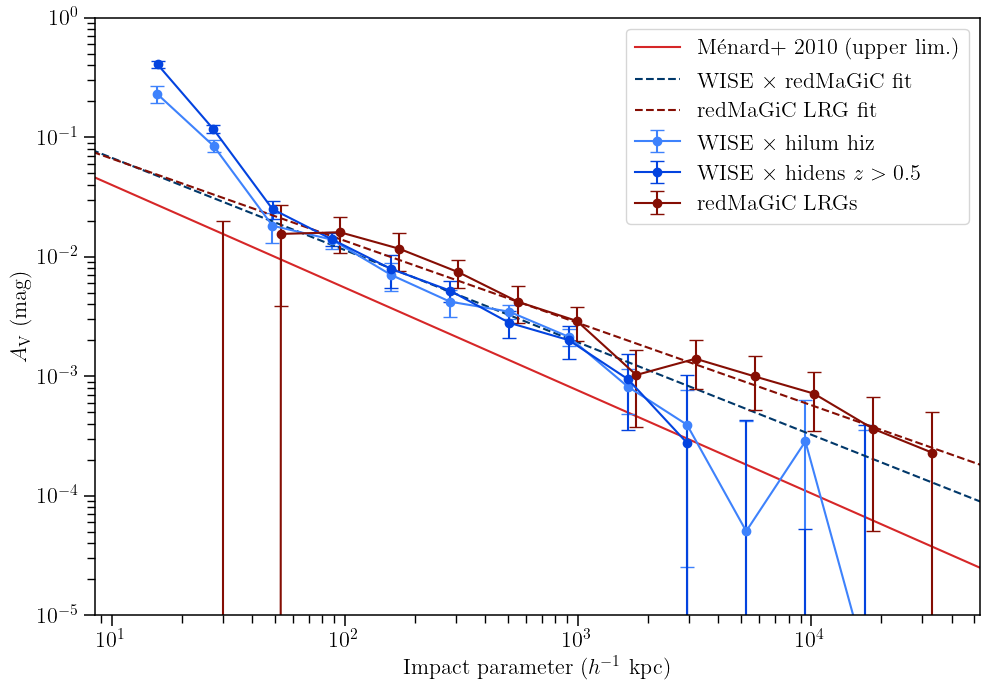

In [20]:
# Set z_theory and z_foreground levels
z_fg = 0.144
z_fg2 = 0.35 # Filtered WISExSCOS
fg_gal_kpc = cosmo.kpc_proper_per_arcmin(z_fg)
fg_gal_kpc2 = cosmo.kpc_proper_per_arcmin(z_fg2)

# Converts us from arcminutes to h^-1 kpc 
# Menard relationship was in terms of h
scl = fg_gal_kpc.value * cosmo.h
scl2 = fg_gal_kpc2.value * cosmo.h

##
## Also plot fits
##
a = res_stacked.params[1]; A = np.exp(a) # Power
b = res_stacked.params[0]; B = np.exp(b) # Coefficient
fit_redmagic = B * (theory_r_arcmin**a)

a = res_lrg.params[1]; A = np.exp(a) # Power
b = res_lrg.params[0]; B = np.exp(b) # Coefficient
fit_lrg = B * (theory_r_arcmin**a)

print(f"  Const: {res_stacked.params[0]:.3e} +/- {res_stacked.bse[0]:.3e}")
print(f"  Slope: {res_stacked.params[1]:.3e} +/- {res_stacked.bse[1]:.3e}")


fig, ax = plt.subplots(figsize=(10, 7), tight_layout=True)

ax.plot(theory_r, av, color='tab:red',
        label=r'M\'{e}nard+ 2010 (upper lim.)')
# What it says

ax.errorbar(
    dk_hiz_newrand_csfd['meanr']*scl, dust_hiz_newrand_csfd,
    yerr=dk_hiz_newrand_csfd['sigma'], fmt='-o', capsize=5, 
    color='xkcd:dodger blue', label=r'WISE $\times$ hilum hiz'
)

ax.errorbar(
    dk_hidens_newrand_csfd['meanr']*scl, dust_hidens_newrand_csfd,
    yerr=dk_hidens_newrand_csfd['sigma'], fmt='-o', capsize=5, 
    color='xkcd:blue', label=r'WISE $\times$ hidens $z>0.5$'
)

ax.plot(
    theory_r_arcmin*scl, fit_redmagic, 
    linestyle='--', color='xkcd:marine blue', 
    label=r'WISE $\times$ redMaGiC fit'
)

ax.errorbar(
    dk_lrg_usebins_csfd['meanr']*scl2, dust_lrg_usebins_csfd,
    yerr=dk_lrg_usebins_csfd['sigma'], fmt='-o', capsize=5, 
    color='xkcd:indian red', label=r'redMaGiC LRGs'
)

ax.plot(
    theory_r_arcmin*scl2, fit_lrg, 
    linestyle='--', color='xkcd:indian red', 
    label=r'redMaGiC LRG fit'
)


ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(0.08*scl, 500*scl)
ax.set_ylim(1E-5, 1)
ax.set_xlabel(r'Impact parameter ($h^{-1}$ kpc)', fontsize=16)
ax.set_ylabel(r'$A_{\rm V}$ (mag)', fontsize=16)
#ax.set_title(r'', fontsize=16)
ax.legend(fontsize=16)

figname = 'dustcorrel_redmagic_csfd_newrand_withfits.png'
fig.savefig(f"/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/{figname}" )
fig.savefig(f"/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/writeup/figures_update2/{figname}" )


# Gaia plots, should do those too

In [21]:
output_path = '/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/systematics_testing/gaia_fg/'

dk_gaia1 = Table.read(output_path+'dustcorrel_hidens_usebins_compensated_signal.txt', header_start=1, format='ascii')
dr_gaia1 = Table.read(output_path+'dustcorrel_hidens_usebins_bg_randoms.txt', header_start=1, format='ascii')
fr_gaia1 = Table.read(output_path+'dustcorrel_hidens_usebins_fg_randoms.txt', header_start=1, format='ascii')
rr_gaia1 = Table.read(output_path+'dustcorrel_hidens_usebins_fgxbg_randoms.txt', header_start=1, format='ascii')

dk_gaia2 = Table.read(output_path+'dustcorrel_hiz_usebins_compensated_signal.txt', header_start=1, format='ascii')
dr_gaia2 = Table.read(output_path+'dustcorrel_hiz_usebins_bg_randoms.txt', header_start=1, format='ascii')
fr_gaia2 = Table.read(output_path+'dustcorrel_hiz_usebins_fg_randoms.txt', header_start=1, format='ascii')
rr_gaia2 = Table.read(output_path+'dustcorrel_hiz_usebins_fgxbg_randoms.txt', header_start=1, format='ascii')

###
### Now define signal 
### 

dust_gaia1 = dk_gaia1['kappa'] - dr_gaia1['kappa'] + rr_gaia1['kappa']
dust_gaia2 = dk_gaia2['kappa'] - dr_gaia2['kappa'] + rr_gaia2['kappa']


## Start with fitting

In [22]:
fit_gaia_hidens = stats.linregress(dk_gaia1['meanlogr'][3:], dust_gaia1[3:])
fit_gaia_hiz = stats.linregress(dk_gaia2['meanlogr'][3:], dust_gaia2[3:])

print("Hidens Gaia\n")
print(fit_gaia_hidens)
print("")

print("Hiz Gaia\n")
print(fit_gaia_hiz)
print("")

print(f"Gaia x high-z fit: {np.exp(fit_gaia_hiz.intercept):.2e} * (meanr)^{fit_gaia_hiz.slope:.2f}")
print(f"Gaia x high-dens fit: {np.exp(fit_gaia_hidens.intercept):.2e} * (meanr)^{fit_gaia_hidens.slope:.2f}")

Hidens Gaia

LinregressResult(slope=0.0007038076599183286, intercept=-0.0022873893962825215, rvalue=0.3451986642509272, pvalue=0.328608934214191, stderr=0.0006765312797066091, intercept_stderr=0.001998867222023205)

Hiz Gaia

LinregressResult(slope=0.0006698044907811136, intercept=-0.002428329670817192, rvalue=0.41684479353486414, pvalue=0.2307592089150169, stderr=0.0005163948448265289, intercept_stderr=0.0015257312656794344)

Gaia x high-z fit: 9.98e-01 * (meanr)^0.00
Gaia x high-dens fit: 9.98e-01 * (meanr)^0.00


In [23]:
print("Gaia x redMaGiC high-dens sample:")
print(f"  Const: {fit_gaia_hidens.intercept:.3e} +/- {fit_gaia_hidens.intercept_stderr:.3e}")
print(f"  Slope: {fit_gaia_hidens.slope:.3e} +/- {fit_gaia_hidens.stderr:.3e}")

print("")

print("Gaia x redMaGiC high-lum high-z sample:")
print(f"  Const: {fit_gaia_hiz.intercept:.3e} +/- {fit_gaia_hiz.intercept_stderr:.3e}")
print(f"  Slope: {fit_gaia_hiz.slope:.3e} +/- {fit_gaia_hiz.stderr:.3e}")


Gaia x redMaGiC high-dens sample:
  Const: -2.287e-03 +/- 1.999e-03
  Slope: 7.038e-04 +/- 6.765e-04

Gaia x redMaGiC high-lum high-z sample:
  Const: -2.428e-03 +/- 1.526e-03
  Slope: 6.698e-04 +/- 5.164e-04


In [24]:
res_gaia2 = do_WLS_fit(dk_gaia2, dust_gaia2, name='Gaia x hi-lum hi-z', log=False)
print(res_gaia2.params)

print("")

print("Gaia x redMaGiC hi-lum hi-z WLS fit:")
print(f"  Const: {res_gaia2.params[0]:.3e} +/- {res_gaia2.bse[0]:.3e}")
print(f"  Slope: {res_gaia2.params[1]:.3e} +/- {res_gaia2.bse[1]:.3e}")



Fit result: Gaia x hi-lum hi-z

                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.002
Model:                            WLS   Adj. R-squared:                 -0.089
Method:                 Least Squares   F-statistic:                   0.02226
Date:                Fri, 23 Aug 2024   Prob (F-statistic):              0.884
Time:                        15:30:35   Log-Likelihood:                 70.136
No. Observations:                  13   AIC:                            -136.3
Df Residuals:                      11   BIC:                            -135.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -3.676e-

/Users/j.mccleary/Software/miniconda3/envs/jupyterlab/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1736: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=13
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


In [25]:
res_gaia1 = do_WLS_fit(dk_gaia1, dust_gaia1, name='Gaia x high-dens', log=False)
print(res_gaia1.params)

print("")

print("Gaia x redMaGiC high-dens WLS fit:")
print(f"  Const: {res_gaia1.params[0]:.3e} +/- {res_gaia1.bse[0]:.3e}")
print(f"  Slope: {res_gaia1.params[1]:.3e} +/- {res_gaia1.bse[1]:.3e}")



Fit result: Gaia x high-dens

                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.049
Model:                            WLS   Adj. R-squared:                 -0.037
Method:                 Least Squares   F-statistic:                    0.5696
Date:                Fri, 23 Aug 2024   Prob (F-statistic):              0.466
Time:                        15:30:35   Log-Likelihood:                 69.030
No. Observations:                  13   AIC:                            -134.1
Df Residuals:                      11   BIC:                            -132.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0003

/Users/j.mccleary/Software/miniconda3/envs/jupyterlab/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1736: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=13
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


## Combined fit

In [26]:
dk_gaia1, dust_gaia1

stacked_gaia_dk = vstack([dk_gaia1, dk_gaia2])
stacked_gaia_dust_arr = np.concatenate([dust_gaia1, dust_gaia2])
stacked_gaia_dk.add_column(stacked_gaia_dust_arr, name='dust_column')
stacked_gaia_dk.sort('meanlogr')
stacked_dust_gaia = np.array(stacked_gaia_dk['dust_column'])
print(stacked_gaia_dk)

 r_nom   meanr  meanlogr    kappa      sigma       weight      npairs          dust_column      
------- ------- -------- ----------- ---------- ----------- ------------ -----------------------
0.13396 0.14402  -1.9503    0.021312   0.052595      434.22       1652.0    0.010711999999999944
0.13396 0.14433  -1.9481    0.022491   0.020843       342.0       1715.0    0.017800999999999956
0.24037 0.25686   -1.372   -0.027387   0.017158      1453.2       5528.0   -0.022747000000000073
0.24037  0.2579  -1.3682   0.0032374   0.020278      1203.9       6037.0    0.004777399999999932
0.43133 0.46069 -0.78792   0.0048103  0.0059786      4556.3      17328.0    0.004450300000000129
0.43133 0.46143 -0.78634   0.0015691  0.0087208      3723.3      18671.0    0.004479099999999958
  0.774  0.8274 -0.20211  -0.0088068  0.0058666     11641.0      58376.0   -0.010026800000000002
  0.774 0.82777 -0.20171   -0.008021   0.004269     14453.0      54973.0   -0.008121000000000045
 1.3889  1.4835  0.38202   0.0

In [27]:
res_stacked_gaia = do_WLS_fit(stacked_gaia_dk, stacked_dust_gaia, name='Gaia x combined redMaGiC', log=False)
print(res_stacked_gaia.params)

print("")

print("Gaia x combined redMaGiC WLS fit:")
print(f"  Const: {res_stacked_gaia.params[0]:.3e} +/- {res_stacked_gaia.bse[0]:.3e}")
print(f"  Slope: {res_stacked_gaia.params[1]:.3e} +/- {res_stacked_gaia.bse[1]:.3e}")



Fit result: Gaia x combined redMaGiC

                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.006
Model:                            WLS   Adj. R-squared:                 -0.035
Method:                 Least Squares   F-statistic:                    0.1458
Date:                Fri, 23 Aug 2024   Prob (F-statistic):              0.706
Time:                        15:30:35   Log-Likelihood:                 138.85
No. Observations:                  26   AIC:                            -273.7
Df Residuals:                      24   BIC:                            -271.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        

In [28]:
print("Gaia x redMaGiC high-dens WLS fit:")
print(f"  Const: {res_gaia1.params[0]:.3e} +/- {res_gaia1.bse[0]:.3e}")
print(f"  Slope: {res_gaia1.params[1]:.3e} +/- {res_gaia1.bse[1]:.3e}")

print("")

print("Gaia x redMaGiC high-lum high-z WLS fit:")
print(f"  Const: {res_gaia2.params[0]:.3e} +/- {res_gaia2.bse[0]:.3e}")
print(f"  Slope: {res_gaia2.params[1]:.3e} +/- {res_gaia2.bse[1]:.3e}")

print("")

print("Gaia x combined redMaGiC WLS fit:")
print(f"  Const: {res_stacked_gaia.params[0]:.3e} +/- {res_stacked_gaia.bse[0]:.3e}")
print(f"  Slope: {res_stacked_gaia.params[1]:.3e} +/- {res_stacked_gaia.bse[1]:.3e}")


Gaia x redMaGiC high-dens WLS fit:
  Const: 3.109e-04 +/- 4.202e-04
  Slope: -6.730e-05 +/- 8.917e-05

Gaia x redMaGiC high-lum high-z WLS fit:
  Const: -3.676e-05 +/- 3.589e-04
  Slope: 1.133e-05 +/- 7.591e-05

Gaia x combined redMaGiC WLS fit:
  Const: 1.116e-04 +/- 2.646e-04
  Slope: -2.139e-05 +/- 5.603e-05


## Plots

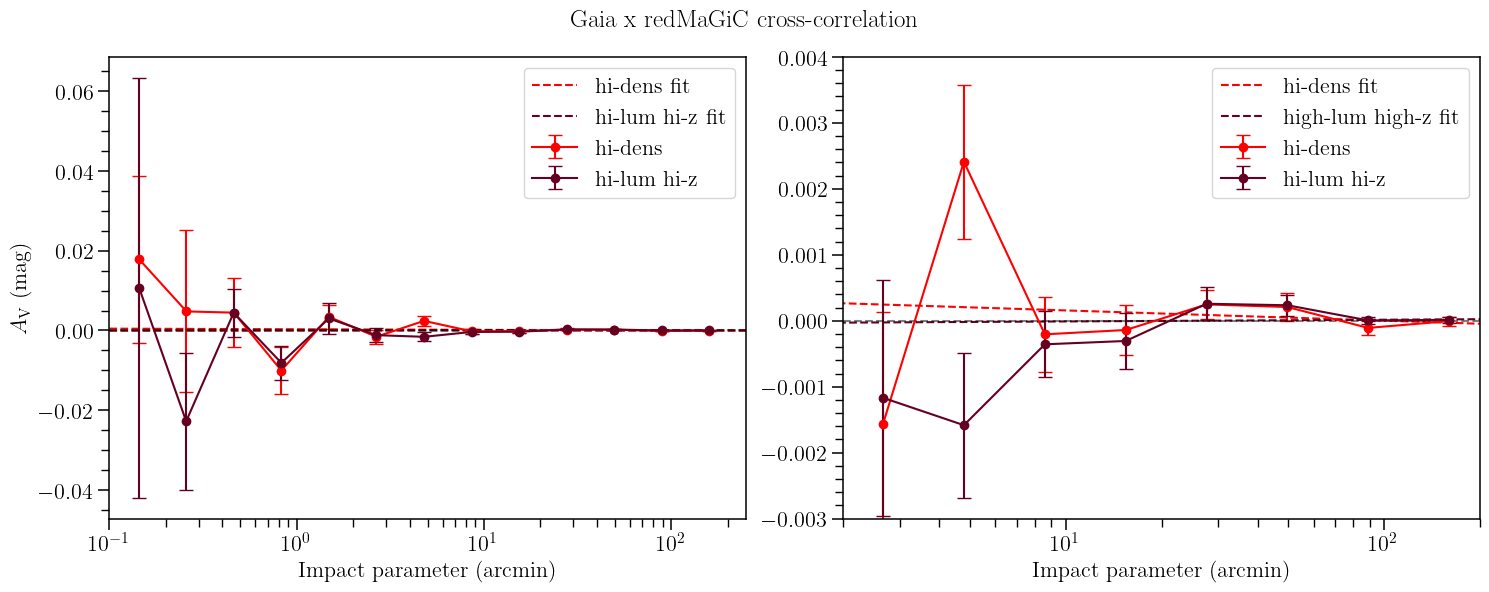

In [29]:
##
## Plot Gaia x redMaGiC results
##

## gaia x high-dens sample
a = res_gaia1.params[1] # Power
b = res_gaia1.params[0] # Coefficient
fit_gaia1 = a * np.log(theory_r_arcmin) + b

# gaia x high-lum high-z sample
fit_gaia2 = res_gaia2.params[1] * np.log(theory_r_arcmin) + res_gaia2.params[0]

fig, axs = plt.subplots(1, 2, figsize=(15, 6), tight_layout=True)

axs[0].errorbar(dk_gaia1['meanr'], dust_gaia1,
            yerr=dk_gaia1['sigma'], fmt='-o', capsize=5, 
            label=r'hi-dens', color='xkcd:fire engine red')
axs[0].plot(theory_r_arcmin, fit_gaia1, ls='--', color='xkcd:fire engine red', 
        label='hi-dens fit')

axs[0].errorbar(dk_gaia2['meanr'], dust_gaia2,
            yerr=dk_gaia2['sigma'], fmt='-o', capsize=5, 
            label=r'hi-lum hi-z', color='xkcd:maroon')
axs[0].plot(theory_r_arcmin, fit_gaia2, ls='--', color='xkcd:maroon', 
        label='hi-lum hi-z fit')

axs[0].set_xscale('log')
axs[0].set_xlim(0.1, 250)
axs[0].axhline(0, linestyle='--', color='k', alpha=0.5)

axs[0].set_xlabel(r'Impact parameter (arcmin)', fontsize=16)
axs[0].set_ylabel(r'$A_{\rm V}$ (mag)', fontsize=16)
axs[0].legend(fontsize=16)

### 
### Inset
###
axs[1].errorbar(dk_gaia1['meanr'][5:], dust_gaia1[5:],
            yerr=dk_gaia1['sigma'][5:], fmt='-o', capsize=5, 
            label=r'hi-dens', color='xkcd:fire engine red')
axs[1].plot(theory_r_arcmin, fit_gaia1, ls='--', color='xkcd:fire engine red', 
        label='hi-dens fit')

axs[1].errorbar(dk_gaia2['meanr'][5:], dust_gaia2[5:],
            yerr=dk_gaia2['sigma'][5:], fmt='-o', capsize=5, 
            label=r'hi-lum hi-z', color='xkcd:maroon')
axs[1].plot(theory_r_arcmin, fit_gaia2, ls='--', color='xkcd:maroon', 
        label='high-lum high-z fit')

axs[1].set_xscale('log')
axs[1].set_xlim(2, 200)
axs[1].set_ylim(-3e-3, 4e-3)
axs[1].axhline(0, linestyle='--', color='k', alpha=0.5)

axs[1].set_xlabel(r'Impact parameter (arcmin)', fontsize=16)
#axs[1].set_ylabel(r'$A_{\rm V}$ (mag)', fontsize=16)
axs[1].legend(fontsize=16)

fig.suptitle('Gaia x redMaGiC cross-correlation', fontsize=18)

figname = 'Gaia_redmagic_crosscorrel_csfd.png'
fig.savefig(f"/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/{figname}" )
fig.savefig(f"/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/writeup/figures_update2/{figname}" )

# DES Star bg plots, should do those too

In [30]:
output_path = '/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/systematics_testing/redmagic_star_bg/'

dk_desstar = Table.read(output_path+'dustcorrel_g23_csfd_usebins_compensated_signal.txt', header_start=1, format='ascii')
dr_desstar = Table.read(output_path+'dustcorrel_g23_csfd_usebins_bg_randoms.txt', header_start=1, format='ascii')
fr_desstar = Table.read(output_path+'dustcorrel_g23_csfd_usebins_fg_randoms.txt', header_start=1, format='ascii')
rr_desstar = Table.read(output_path+'dustcorrel_g23_csfd_usebins_fgxbg_randoms.txt', header_start=1, format='ascii')

dk_desstar2 = Table.read(output_path+'dustcorrel_csfd_new_wiserand_compensated_signal.txt', header_start=1, format='ascii')
dr_desstar2 = Table.read(output_path+'dustcorrel_csfd_new_wiserand_bg_randoms.txt', header_start=1, format='ascii')
fr_desstar2 = Table.read(output_path+'dustcorrel_csfd_new_wiserand_fg_randoms.txt', header_start=1, format='ascii')
rr_desstar2 = Table.read(output_path+'dustcorrel_csfd_new_wiserand_fgxbg_randoms.txt', header_start=1, format='ascii')

###
### Now define signal 
### 

dust_desstar = dk_desstar['kappa'] - dr_desstar['kappa'] + rr_desstar['kappa']
dust_desstar2 = dk_desstar2['kappa'] - dr_desstar2['kappa'] + rr_desstar2['kappa']


## Start with fitting

In [31]:
fit_desstar = stats.linregress(dk_desstar['meanlogr'], dust_desstar)
fit_desstar2 = stats.linregress(dk_desstar2['meanlogr'], dust_desstar2)

print("WISExSCOS x DES Y3 stars LSQ:")
print(f"  Const: {fit_desstar.intercept:.3e} +/- {fit_desstar.intercept_stderr:.3e}")
print(f"  Slope: {fit_desstar.slope:.3e} +/- {fit_desstar.stderr:.3e}")

print("")

print("WISExSCOS updated rand x DES Y3 stars LSQ:")
print(f"  Const: {fit_desstar2.intercept:.3e} +/- {fit_desstar2.intercept_stderr:.3e}")
print(f"  Slope: {fit_desstar2.slope:.3e} +/- {fit_desstar2.stderr:.3e}")


WISExSCOS x DES Y3 stars LSQ:
  Const: -9.423e-04 +/- 1.372e-03
  Slope: 2.343e-04 +/- 5.114e-04

WISExSCOS updated rand x DES Y3 stars LSQ:
  Const: 1.878e-04 +/- 1.265e-03
  Slope: -3.150e-05 +/- 4.713e-04


In [32]:
res_desstar = do_WLS_fit(dk_desstar, dust_desstar, name='WISExSCOS x DES star', log=False)
print(res_desstar.params)

print("")

print("WISExSCOS orig rand x DES star WLS fit results:")
print(f"  Coeff: {res_desstar.params[0]:.3e} +/- {res_desstar.bse[0]:.3e}")
print(f"  Slope: {res_desstar.params[1]:.3e} +/- {res_desstar.bse[1]:.3e}")



Fit result: WISExSCOS x DES star

                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.008
Model:                            WLS   Adj. R-squared:                 -0.082
Method:                 Least Squares   F-statistic:                   0.08766
Date:                Fri, 23 Aug 2024   Prob (F-statistic):              0.773
Time:                        15:30:35   Log-Likelihood:                 69.888
No. Observations:                  13   AIC:                            -135.8
Df Residuals:                      11   BIC:                            -134.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.

/Users/j.mccleary/Software/miniconda3/envs/jupyterlab/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1736: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=13
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


In [33]:
res_desstar2 = do_WLS_fit(dk_desstar2, dust_desstar2, name='WISExSCOS rand2 x DES star', log=False)
print(res_desstar2.params)

print("")

print("WISExSCOS updated rand x DES star WLS fit results:")
print(f"  Coeff: {res_desstar2.params[0]:.3e} +/- {res_desstar2.bse[0]:.3e}")
print(f"  Slope: {res_desstar2.params[1]:.3e} +/- {res_desstar2.bse[1]:.3e}")



Fit result: WISExSCOS rand2 x DES star

                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.147
Model:                            WLS   Adj. R-squared:                  0.070
Method:                 Least Squares   F-statistic:                     1.900
Date:                Fri, 23 Aug 2024   Prob (F-statistic):              0.195
Time:                        15:30:35   Log-Likelihood:                 69.816
No. Observations:                  13   AIC:                            -135.6
Df Residuals:                      11   BIC:                            -134.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      

/Users/j.mccleary/Software/miniconda3/envs/jupyterlab/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1736: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=13
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


In [34]:
print("WISExSCOS orig rand x DES star WLS fit results:")
print(f"  Coeff: {res_desstar.params[0]:.3e} +/- {res_desstar.bse[0]:.3e}")
print(f"  Slope: {res_desstar.params[1]:.3e} +/- {res_desstar.bse[1]:.3e}")

print("")

print("WISExSCOS updated rand x DES star WLS fit results:")
print(f"  Coeff: {res_desstar2.params[0]:.3e} +/- {res_desstar2.bse[0]:.3e}")
print(f"  Slope: {res_desstar2.params[1]:.3e} +/- {res_desstar2.bse[1]:.3e}")


WISExSCOS orig rand x DES star WLS fit results:
  Coeff: -2.255e-04 +/- 4.807e-04
  Slope: 3.561e-05 +/- 1.203e-04

WISExSCOS updated rand x DES star WLS fit results:
  Coeff: -5.348e-04 +/- 4.500e-04
  Slope: 1.770e-04 +/- 1.284e-04


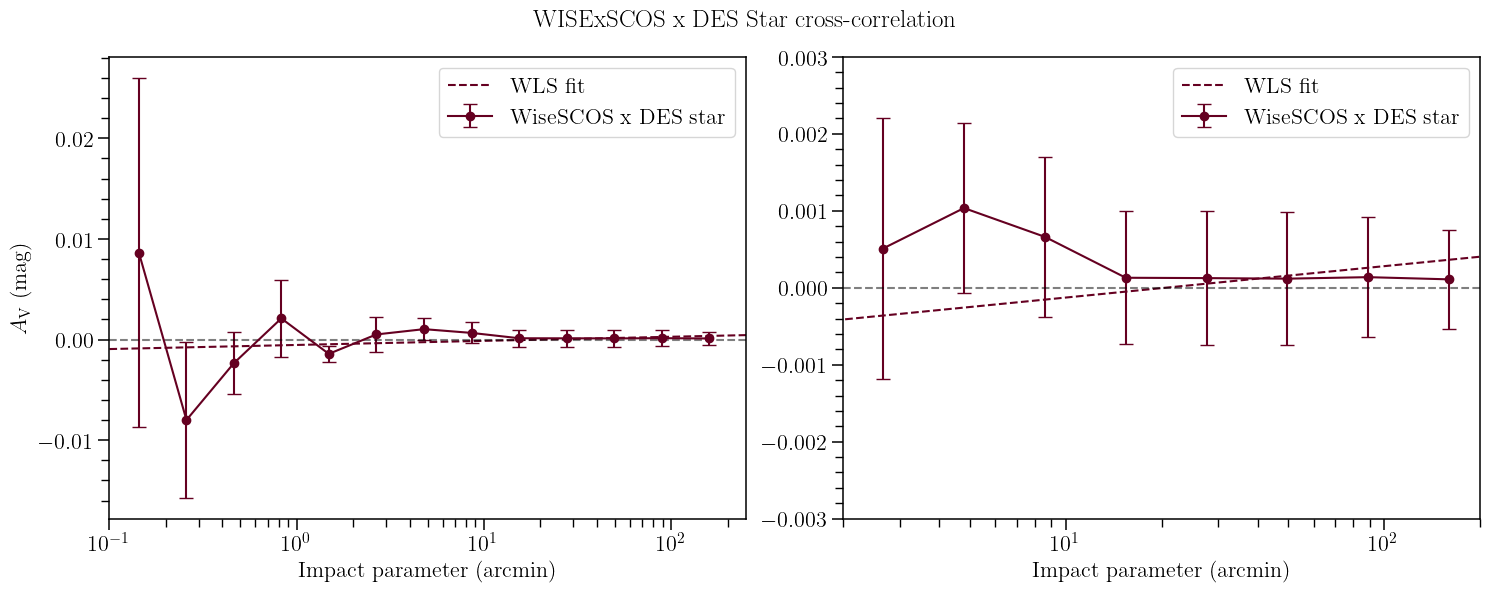

In [35]:
## gaia x high-dens sample
a = res_desstar.params[1] # Power
b = res_desstar.params[0] # Coefficient
fit_desstar = a * dk_desstar['meanlogr'] + b

# gaia x high-lum high-z sample
#fit_desstar2 = res_desstar2.params[1] * dk_desstar2['meanlogr'] + res_desstar2.params[0]
fit_desstar2 = res_desstar2.params[1] * np.log(theory_r_arcmin) + res_desstar2.params[0]

fig, axs = plt.subplots(1, 2, figsize=(15, 6), tight_layout=True)

'''
axs[0].errorbar(dk_desstar['meanr'], dust_desstar,
            yerr=dk_desstar['sigma'], fmt='-o', capsize=5, 
            label=r'DES star bg', color='xkcd:fire engine red')
axs[0].plot(dk_desstar['meanr'], fit_desstar, ls='--', color='xkcd:fire engine red', 
        label='DES star fit')
'''

axs[0].errorbar(dk_desstar2['meanr'], dust_desstar2,
            yerr=dk_desstar2['sigma'], fmt='-o', capsize=5, 
            label=r'WiseSCOS x DES star', color='xkcd:maroon')
axs[0].plot(theory_r_arcmin, fit_desstar2, ls='--', color='xkcd:maroon', 
        label='WLS fit')

axs[0].set_xscale('log')
axs[0].set_xlim(0.1, 250)
axs[0].axhline(0, linestyle='--', color='k', alpha=0.5)

axs[0].set_xlabel(r'Impact parameter (arcmin)', fontsize=16)
axs[0].set_ylabel(r'$A_{\rm V}$ (mag)', fontsize=16)
axs[0].legend(fontsize=16)

### 
### Inset
###
'''
axs[1].errorbar(dk_desstar['meanr'][5:], dust_desstar[5:],
            yerr=dk_desstar['sigma'][5:], fmt='-o', capsize=5, 
            label=r'DES star bg', color='xkcd:fire engine red')
axs[1].plot(dk_desstar['meanr'][1:], fit_desstar[1:], ls='--', color='xkcd:fire engine red', 
        label='DES star bg fit')
'''
axs[1].errorbar(dk_desstar2['meanr'][5:], dust_desstar2[5:],
            yerr=dk_desstar2['sigma'][5:], fmt='-o', capsize=5, 
            label=r'WiseSCOS x DES star', color='xkcd:maroon')
axs[1].plot(theory_r_arcmin, fit_desstar2, ls='--', color='xkcd:maroon', 
        label='WLS fit')


axs[1].set_xscale('log')
axs[1].set_xlim(2, 200)
axs[1].set_ylim(-3e-3, 3e-3)
axs[1].axhline(0, linestyle='--', color='k', alpha=0.5)

axs[1].set_xlabel(r'Impact parameter (arcmin)', fontsize=16)
#axs[1].set_ylabel(r'$A_{\rm V}$ (mag)', fontsize=16)
axs[1].legend(fontsize=16)

fig.suptitle('WISExSCOS x DES Star cross-correlation', fontsize=18)

figname = 'desstar_crosscorrel_csfd.png'
fig.savefig(f"/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/{figname}" )
fig.savefig(f"/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/writeup/figures_update2/{figname}" )

# Bonus round: GWSLC x SDSS

In [36]:
###
### Define a little remove row function
###

def remove_rows(tab, rows=None):
    if (rows == None) or (len(list(rows))==0):
        raise ValueError("Need to supply a list of rows")
    trimmed_tab = copy.deepcopy(tab)
    trimmed_tab.remove_rows(list(rows))
    return trimmed_tab

In [37]:
###
### Read in files
###
output_path = '/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/sdss_gwslc_csfd/'

dk_gwslc = Table.read(output_path+'dustcorrel_csfd_compensated_signal.txt', header_start=1, format='ascii')
dr_gwslc = Table.read(output_path+'dustcorrel_csfd_bg_randoms.txt', header_start=1, format='ascii')
fr_gwslc = Table.read(output_path+'dustcorrel_csfd_fg_randoms.txt', header_start=1, format='ascii')
rr_gwslc = Table.read(output_path+'dustcorrel_csfd_fgxbg_randoms.txt', header_start=1, format='ascii')

###
### For fitting purposes, also define a partial dust vector
###
partial_dk_gwslc = remove_rows(dk_gwslc, [0, 1, 2, 4, 5, 6, 7])
partial_dr_gwslc = remove_rows(dr_gwslc, [0, 1, 2, 4, 5, 6, 7])
partial_fr_gwslc = remove_rows(fr_gwslc, [0, 1, 2, 4, 5, 6, 7])
partial_rr_gwslc = remove_rows(rr_gwslc, [0, 1, 2, 4, 5, 6, 7])

###
### Define dust vectors
###
dust_gwslc = dk_gwslc['kappa'] - dr_gwslc['kappa'] + rr_gwslc['kappa']
partial_dust_gwslc = partial_dk_gwslc['kappa'] - partial_dr_gwslc['kappa'] + partial_rr_gwslc['kappa']



In [38]:
res_gwslc = do_WLS_fit(
    dk_gwslc, dust_gwslc, 
    name='GWSLC x SDSS', start=8, log=True
)
print(res_gwslc.params)

print("")

res_partial_gwslc = do_WLS_fit(
    partial_dk_gwslc, partial_dust_gwslc, 
    name='partial GWSLC x SDSS', log=True
)
print(res_partial_gwslc.params)

print("")

print(
    f"GWSLC x SDSS Fit: \
    {np.exp(res_gwslc.params[0]):.2e} * (meanr)^{res_gwslc.params[1]:.2f}"
)
print(
    f"partial GWSLC x SDSS Fit: \
    {np.exp(res_partial_gwslc.params[0]):.2e} * (meanr)^{res_partial_gwslc.params[1]:.2f}"
)


Fit result: GWSLC x SDSS

                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.893
Model:                            WLS   Adj. R-squared:                  0.857
Method:                 Least Squares   F-statistic:                     25.07
Date:                Fri, 23 Aug 2024   Prob (F-statistic):             0.0153
Time:                        15:30:36   Log-Likelihood:                0.52435
No. Observations:                   5   AIC:                             2.951
Df Residuals:                       3   BIC:                             2.170
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.2345    

/Users/j.mccleary/Software/miniconda3/envs/jupyterlab/lib/python3.11/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "
/Users/j.mccleary/Software/miniconda3/envs/jupyterlab/lib/python3.11/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


  Const: -4.234e+00 +/- 6.150e-01
  Slope: -7.535e-01 +/- 1.505e-01


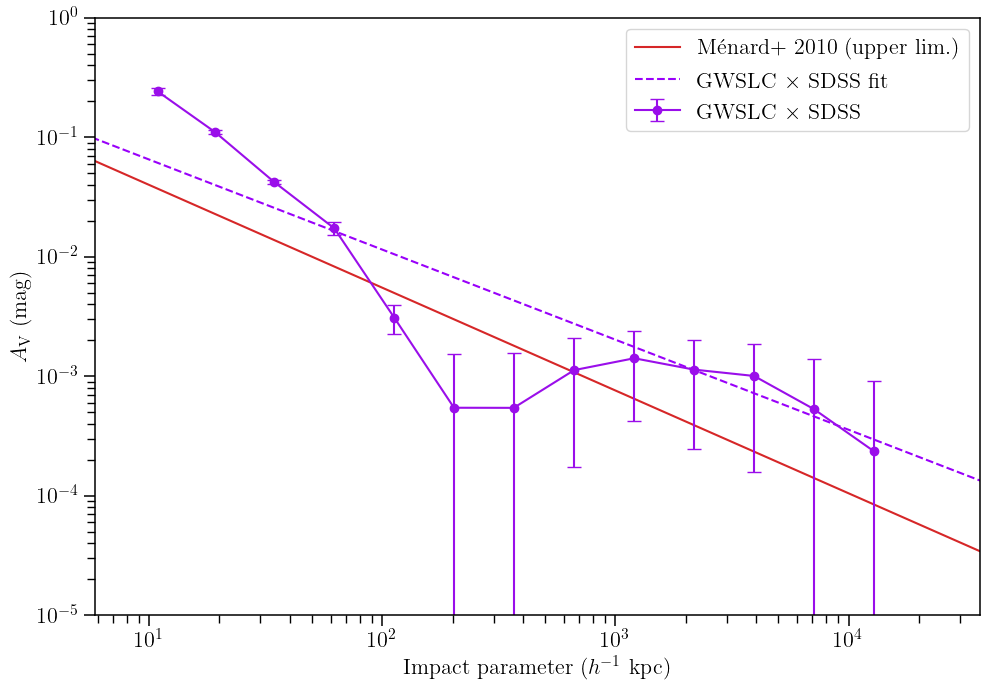

In [39]:
# Set z_theory and z_foreground levels
z_fg = 0.094
z_fg2 = 0.35 # Filtered WISExSCOS
fg_gal_kpc = cosmo.kpc_proper_per_arcmin(z_fg)
fg_gal_kpc2 = cosmo.kpc_proper_per_arcmin(z_fg)

# Converts us from arcminutes to h^-1 kpc 
# Menard relationship was in terms of h
scl = fg_gal_kpc.value * cosmo.h
scl2 = fg_gal_kpc2.value * cosmo.h

##
## Also plot fits
##
a = res_gwslc.params[1]; A = np.exp(a) # Power
b = res_gwslc.params[0]; B = np.exp(b) # Coefficient
fit_gwslc = B * (theory_r_arcmin**a)

print(f"  Const: {res_gwslc.params[0]:.3e} +/- {res_gwslc.bse[0]:.3e}")
print(f"  Slope: {res_gwslc.params[1]:.3e} +/- {res_gwslc.bse[1]:.3e}")


fig, ax = plt.subplots(figsize=(10, 7), tight_layout=True)

ax.plot(theory_r, av, color='tab:red',
        label=r'M\'{e}nard+ 2010 (upper lim.)')
# What it says

ax.errorbar(
    dk_gwslc['meanr']*scl, dust_gwslc,
    yerr=dk_gwslc['sigma'], fmt='-o', capsize=5, 
    color='xkcd:violet', label=r'GWSLC $\times$ SDSS'
)

ax.plot(
    theory_r_arcmin*scl, fit_gwslc, 
    linestyle='--', color='xkcd:vivid purple', 
    label=r'GWSLC $\times$ SDSS fit'
)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(0.08*scl, 500*scl)
ax.set_ylim(1E-5, 1)
ax.set_xlabel(r'Impact parameter ($h^{-1}$ kpc)', fontsize=16)
ax.set_ylabel(r'$A_{\rm V}$ (mag)', fontsize=16)
#ax.set_title(r'', fontsize=16)
ax.legend(fontsize=16)

figname = 'dustcorrel_gwslc_csfd_withfit.png'
fig.savefig(f"/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/{figname}" )
fig.savefig(f"/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/writeup/figures_update2/{figname}" )


  Const: -4.234e+00 +/- 6.150e-01
  Slope: -7.535e-01 +/- 1.505e-01


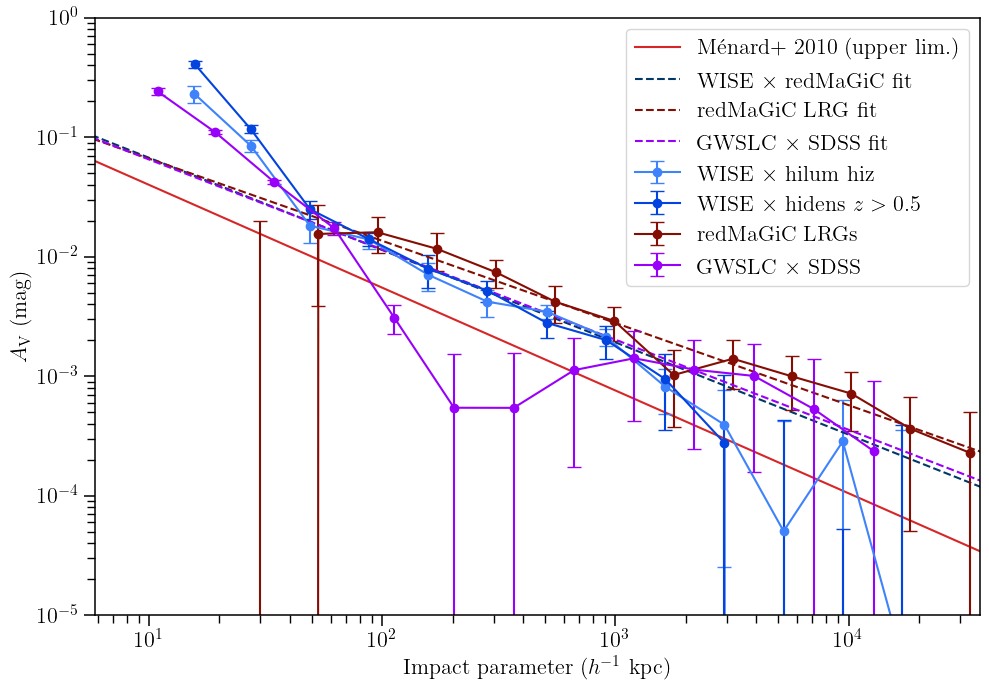

In [40]:
z_fg0 = 0.094
z_fg = 0.144
z_fg2 = 0.35 # Filtered WISExSCOS
fg_gal_kpc0 = cosmo.kpc_proper_per_arcmin(z_fg0)
fg_gal_kpc = cosmo.kpc_proper_per_arcmin(z_fg)
fg_gal_kpc2 = cosmo.kpc_proper_per_arcmin(z_fg2)

# Converts us from arcminutes to h^-1 kpc 
# Menard relationship was in terms of h
scl0 = fg_gal_kpc0.value * cosmo.h
scl = fg_gal_kpc.value * cosmo.h
scl2 = fg_gal_kpc2.value * cosmo.h

##
## Also plot fits
##
a = res_stacked.params[1]; A = np.exp(a) # Power
b = res_stacked.params[0]; B = np.exp(b) # Coefficient
fit_redmagic = B * (theory_r_arcmin**a)

a = res_lrg.params[1]; A = np.exp(a) # Power
b = res_lrg.params[0]; B = np.exp(b) # Coefficient
fit_lrg = B * (theory_r_arcmin**a)

a = res_gwslc.params[1]; A = np.exp(a) # Power
b = res_gwslc.params[0]; B = np.exp(b) # Coefficient
fit_gwslc = B * (theory_r_arcmin**a)

print(f"  Const: {res_gwslc.params[0]:.3e} +/- {res_gwslc.bse[0]:.3e}")
print(f"  Slope: {res_gwslc.params[1]:.3e} +/- {res_gwslc.bse[1]:.3e}")


fig, ax = plt.subplots(figsize=(10, 7), tight_layout=True)

ax.plot(theory_r, av, color='tab:red',
        label=r'M\'{e}nard+ 2010 (upper lim.)')
# What it says

ax.errorbar(
    dk_hiz_newrand_csfd['meanr']*scl, dust_hiz_newrand_csfd,
    yerr=dk_hiz_newrand_csfd['sigma'], fmt='-o', capsize=5, 
    color='xkcd:dodger blue', label=r'WISE $\times$ hilum hiz'
)
ax.errorbar(
    dk_hidens_newrand_csfd['meanr']*scl, dust_hidens_newrand_csfd,
    yerr=dk_hidens_newrand_csfd['sigma'], fmt='-o', capsize=5, 
    color='xkcd:blue', label=r'WISE $\times$ hidens $z>0.5$'
)
ax.plot(
    theory_r_arcmin*scl, fit_redmagic, 
    linestyle='--', color='xkcd:marine blue', 
    label=r'WISE $\times$ redMaGiC fit'
)
ax.errorbar(
    dk_lrg_usebins_csfd['meanr']*scl2, dust_lrg_usebins_csfd,
    yerr=dk_lrg_usebins_csfd['sigma'], fmt='-o', capsize=5, 
    color='xkcd:indian red', label=r'redMaGiC LRGs'
)
ax.plot(
    theory_r_arcmin*scl2, fit_lrg, 
    linestyle='--', color='xkcd:indian red', 
    label=r'redMaGiC LRG fit'
)
ax.errorbar(
    dk_gwslc['meanr']*scl0, dust_gwslc,
    yerr=dk_gwslc['sigma'], fmt='-o', capsize=5, 
    color='xkcd:vivid purple', label=r'GWSLC $\times$ SDSS'
)
ax.plot(
    theory_r_arcmin*scl0, fit_gwslc, 
    linestyle='--', color='xkcd:vivid purple', 
    label=r'GWSLC $\times$ SDSS fit'
)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(0.08*scl0, 500*scl0)
ax.set_ylim(1E-5, 1)
ax.set_xlabel(r'Impact parameter ($h^{-1}$ kpc)', fontsize=16)
ax.set_ylabel(r'$A_{\rm V}$ (mag)', fontsize=16)
#ax.set_title(r'', fontsize=16)
ax.legend(fontsize=16)

figname = 'dustcorrel_all_csfd_withfit.png'
fig.savefig(f"/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/{figname}" )
fig.savefig(f"/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/writeup/figures_update2/{figname}" )


  Const: -4.234e+00 +/- 6.150e-01
  Slope: -7.535e-01 +/- 1.505e-01


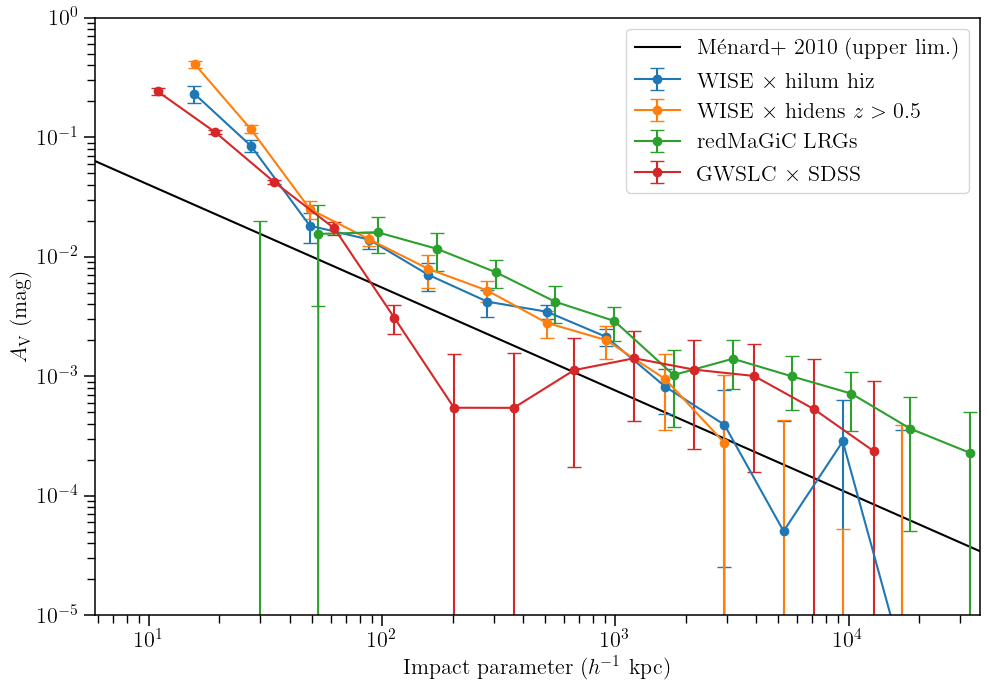

In [41]:
z_fg0 = 0.094
z_fg = 0.144
z_fg2 = 0.35 # Filtered WISExSCOS
fg_gal_kpc0 = cosmo.kpc_proper_per_arcmin(z_fg0)
fg_gal_kpc = cosmo.kpc_proper_per_arcmin(z_fg)
fg_gal_kpc2 = cosmo.kpc_proper_per_arcmin(z_fg2)

# Converts us from arcminutes to h^-1 kpc 
# Menard relationship was in terms of h
scl0 = fg_gal_kpc0.value * cosmo.h
scl = fg_gal_kpc.value * cosmo.h
scl2 = fg_gal_kpc2.value * cosmo.h

##
## Also plot fits
##
a = res_stacked.params[1]; A = np.exp(a) # Power
b = res_stacked.params[0]; B = np.exp(b) # Coefficient
fit_redmagic = B * (theory_r_arcmin**a)

a = res_lrg.params[1]; A = np.exp(a) # Power
b = res_lrg.params[0]; B = np.exp(b) # Coefficient
fit_lrg = B * (theory_r_arcmin**a)

a = res_gwslc.params[1]; A = np.exp(a) # Power
b = res_gwslc.params[0]; B = np.exp(b) # Coefficient
fit_gwslc = B * (theory_r_arcmin**a)

print(f"  Const: {res_gwslc.params[0]:.3e} +/- {res_gwslc.bse[0]:.3e}")
print(f"  Slope: {res_gwslc.params[1]:.3e} +/- {res_gwslc.bse[1]:.3e}")


fig, ax = plt.subplots(figsize=(10, 7), tight_layout=True)

ax.plot(theory_r, av, color='k',
        label=r'M\'{e}nard+ 2010 (upper lim.)')
# What it says

ax.errorbar(
    dk_hiz_newrand_csfd['meanr']*scl, dust_hiz_newrand_csfd,
    yerr=dk_hiz_newrand_csfd['sigma'], fmt='-o', capsize=5, 
    label=r'WISE $\times$ hilum hiz'
)
ax.errorbar(
    dk_hidens_newrand_csfd['meanr']*scl, dust_hidens_newrand_csfd,
    yerr=dk_hidens_newrand_csfd['sigma'], fmt='-o', capsize=5, 
    label=r'WISE $\times$ hidens $z>0.5$'
)
'''
ax.plot(
    theory_r_arcmin*scl, fit_redmagic, 
    linestyle='--', 
    label=r'WISE $\times$ redMaGiC fit'
)
'''
ax.errorbar(
    dk_lrg_usebins_csfd['meanr']*scl2, dust_lrg_usebins_csfd,
    yerr=dk_lrg_usebins_csfd['sigma'], fmt='-o', capsize=5, 
    label=r'redMaGiC LRGs'
)
'''
ax.plot(
    theory_r_arcmin*scl2, fit_lrg, 
    linestyle='--', color='xkcd:indian red', 
    label=r'redMaGiC LRG fit'
)
'''
ax.errorbar(
    dk_gwslc['meanr']*scl0, dust_gwslc,
    yerr=dk_gwslc['sigma'], fmt='-o', capsize=5, 
    label=r'GWSLC $\times$ SDSS'
)
'''
ax.plot(
    theory_r_arcmin*scl0, fit_gwslc, 
    linestyle='--', color='xkcd:vivid purple', 
    label=r'GWSLC $\times$ SDSS fit'
)
'''

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(0.08*scl0, 500*scl0)
ax.set_ylim(1E-5, 1)
ax.set_xlabel(r'Impact parameter ($h^{-1}$ kpc)', fontsize=16)
ax.set_ylabel(r'$A_{\rm V}$ (mag)', fontsize=16)
#ax.set_title(r'', fontsize=16)
ax.legend(fontsize=16)

figname = 'dustcorrel_all_csfd_withfit_uglycolor.png'
fig.savefig(f"/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/{figname}" )
fig.savefig(f"/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/writeup/figures_update2/{figname}" )


# Hiz fg x Low-z bg

In [42]:
###
### Read in files
###
output_path = '/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/systematics_testing/hiz_fg_x_lowz_bg_v2/'

dk_hiz_fg = Table.read(output_path+'dustcorrel_g23_csfd_usebins_compensated_signal.txt', header_start=1, format='ascii')
dr_hiz_fg = Table.read(output_path+'dustcorrel_g23_csfd_usebins_bg_randoms.txt', header_start=1, format='ascii')
fr_hiz_fg = Table.read(output_path+'dustcorrel_g23_csfd_usebins_fg_randoms.txt', header_start=1, format='ascii')
rr_hiz_fg = Table.read(output_path+'dustcorrel_g23_csfd_usebins_fgxbg_randoms.txt', header_start=1, format='ascii')

dust_hiz_fg = dk_hiz_fg['kappa'] - dr_hiz_fg['kappa'] + rr_hiz_fg['kappa']


In [43]:
res_hiz_fg = do_WLS_fit(
    dk_hiz_fg, dust_hiz_fg, 
    name='hiz fg x lowz bg', log=False
)
print(res_hiz_fg.params)

print("")

print(
    f"hiz fg x lowz bg fit: \
    {np.exp(res_hiz_fg.params[0]):.2e} * (meanr)^{res_hiz_fg.params[1]:.2f}"
)



Fit result: hiz fg x lowz bg

                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.557
Model:                            WLS   Adj. R-squared:                  0.516
Method:                 Least Squares   F-statistic:                     13.82
Date:                Fri, 23 Aug 2024   Prob (F-statistic):            0.00340
Time:                        15:30:38   Log-Likelihood:                 72.198
No. Observations:                  13   AIC:                            -140.4
Df Residuals:                      11   BIC:                            -139.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0020

/Users/j.mccleary/Software/miniconda3/envs/jupyterlab/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1736: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=13
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


  Const: 2.036e-03 +/- 4.442e-04
  Slope: -3.952e-04 +/- 1.063e-04


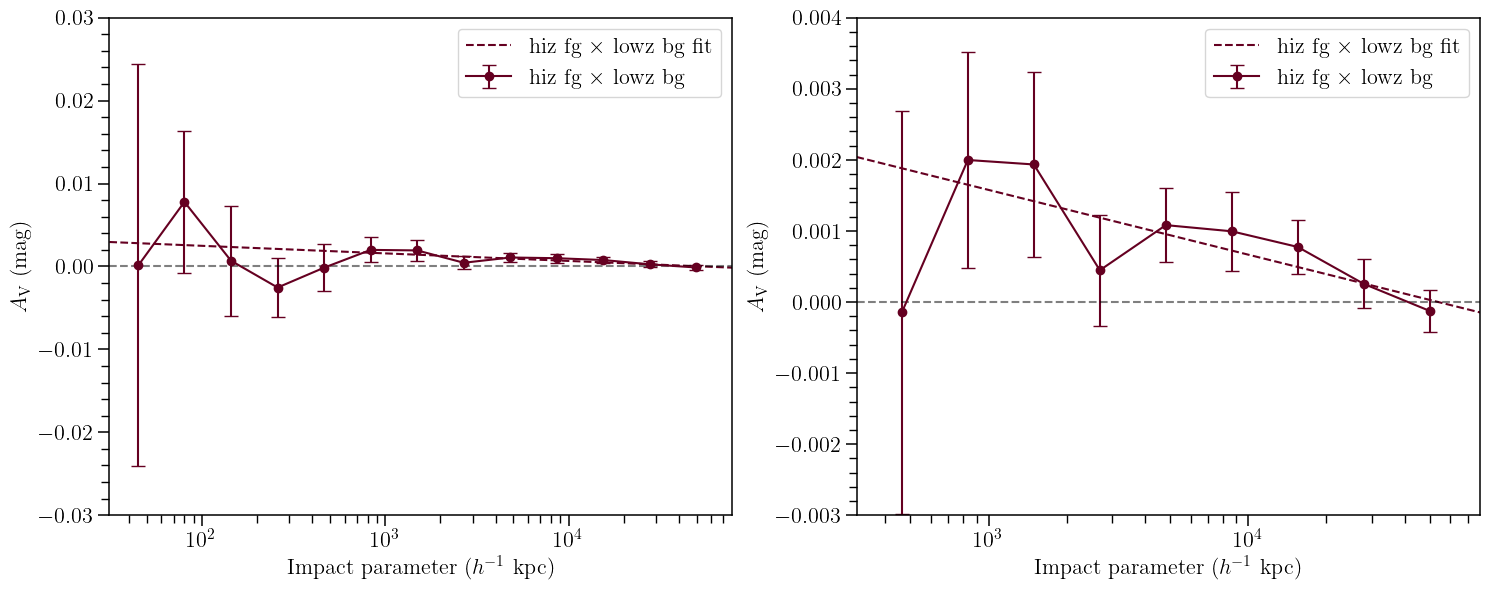

In [44]:
# Set z_theory and z_foreground levels
z_fg = 0.79
fg_gal_kpc = cosmo.kpc_proper_per_arcmin(z_fg)

# Converts us from arcminutes to h^-1 kpc 
# Menard relationship was in terms of h
scl = fg_gal_kpc.value * cosmo.h
#scl=1
##
## Also plot fits
##
a = res_hiz_fg.params[1]; A = np.exp(a) # Power
b = res_hiz_fg.params[0]; B = np.exp(b) # Coefficient
fit_hiz_fg = B * (theory_r_arcmin**a)

print(f"  Const: {res_hiz_fg.params[0]:.3e} +/- {res_hiz_fg.bse[0]:.3e}")
print(f"  Slope: {res_hiz_fg.params[1]:.3e} +/- {res_hiz_fg.bse[1]:.3e}")


fig, axs = plt.subplots(1, 2, figsize=(15, 6), tight_layout=True)

#ax.plot(theory_r, av, color='tab:red',
#        label=r'M\'{e}nard+ 2010 (upper lim.)')
# What it says

axs[0].errorbar(
    dk_hiz_fg['meanr']*scl, dust_hiz_fg,
    yerr=dk_hiz_fg['sigma'], fmt='-o', capsize=5, 
    color='xkcd:maroon', label=r'hiz fg $\times$ lowz bg'
)
axs[0].plot(
    theory_r_arcmin*scl, fit_hiz_fg-1, 
    linestyle='--', color='xkcd:maroon', 
    label=r'hiz fg $\times$ lowz bg fit'
)

axs[0].set_xscale('log')
axs[0].set_xlim(0.1*scl, 250*scl)
axs[0].axhline(0, linestyle='--', color='k', alpha=0.5)
axs[0].set_ylim(-3e-2, 3e-2)

axs[0].set_xlabel(r'Impact parameter ($h^{-1}$ kpc)', fontsize=16)
axs[0].set_ylabel(r'$A_{\rm V}$ (mag)', fontsize=16)
#ax.set_title(r'', fontsize=16)
axs[0].legend(fontsize=16)

###
### Inset, zoom in 
###

axs[1].errorbar(
    dk_hiz_fg['meanr'][4:]*scl, dust_hiz_fg[4:],
    yerr=dk_hiz_fg['sigma'][4:], fmt='-o', capsize=5, 
    color='xkcd:maroon', label=r'hiz fg $\times$ lowz bg'
)

axs[1].plot(
    theory_r_arcmin*scl, fit_hiz_fg-1, 
    linestyle='--', color='xkcd:maroon', 
    label=r'hiz fg $\times$ lowz bg fit'
)

axs[1].set_xscale('log')
axs[1].set_xlim(1*scl, 250*scl)
axs[1].axhline(0, linestyle='--', color='k', alpha=0.5)
axs[1].set_ylim(-3e-3, 4e-3)

axs[1].set_xlabel(r'Impact parameter ($h^{-1}$ kpc)', fontsize=16)
axs[1].set_ylabel(r'$A_{\rm V}$ (mag)', fontsize=16)
#ax.set_title(r'', fontsize=16)
axs[1].legend(fontsize=16)


figname = 'dustcorrel_hiz_fg_x_lowz_bg_withfit.png'
fig.savefig(f"/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/{figname}" )
fig.savefig(f"/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/writeup/figures_update2/{figname}" )


In [45]:
res_hiz_fg.params

array([ 0.00203558, -0.0003952 ])

In [46]:
res_gaia1.params

array([ 3.10942951e-04, -6.72977081e-05])

In [47]:
a = res_gaia1.params[1]; A = np.exp(a) # Power
b = res_gaia1.params[0]; B = np.exp(b) # Coefficient
fit_hiz_fg = B * (theory_r_arcmin**a)


In [48]:
fit_hiz_fg

array([1.00108633, 1.00100468, 1.00092305, 1.00084142, 1.0007598 ,
       1.00067818, 1.00059657, 1.00051497, 1.00043337, 1.00035178,
       1.0002702 , 1.00018862, 1.00010706, 1.00002549, 0.99994394,
       0.99986239, 0.99978085, 0.99969931, 0.99961778, 0.99953626])